In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
columns = [
    "id", "diagnosis",

    "radius_mean", "texture_mean", "perimeter_mean", "area_mean",
    "smoothness_mean", "compactness_mean", "concavity_mean",
    "concave_points_mean", "symmetry_mean", "fractal_dimension_mean",

    "radius_se", "texture_se", "perimeter_se", "area_se",
    "smoothness_se", "compactness_se", "concavity_se",
    "concave_points_se", "symmetry_se", "fractal_dimension_se",

    "radius_worst", "texture_worst", "perimeter_worst", "area_worst",
    "smoothness_worst", "compactness_worst", "concavity_worst",
    "concave_points_worst", "symmetry_worst", "fractal_dimension_worst"
]

df = pd.read_csv(
    "../data/raw/breast/wdbc.data",
    header=None,
    names=columns
)

print("Dataset loaded:", df.shape)

Dataset loaded: (569, 32)


In [3]:
df["target"] = df["diagnosis"].map({
    "B": 0,
    "M": 1
})

X = df.drop(columns=["id", "diagnosis", "target"])
y = df["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 30)
y shape: (569,)


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


## pre processing


In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed!")

Scaling completed!


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier


In [7]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=5000,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Naive Bayes": GaussianNB(),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "SVM": SVC(
        probability=True,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )
}

print("Models created:", len(models))

Models created: 7


## Cross-validation

In [8]:
from sklearn.model_selection import cross_val_score

cv_results = {}

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=5,
        scoring="accuracy"
    )
    
    cv_results[name] = scores
    
    print(
        f"{name}: "
        f"Mean Accuracy = {scores.mean():.4f} "
        f"+/- {scores.std():.4f}"
    )

Logistic Regression: Mean Accuracy = 0.9714 +/- 0.0112
KNN: Mean Accuracy = 0.9626 +/- 0.0237
Naive Bayes: Mean Accuracy = 0.9385 +/- 0.0256
Decision Tree: Mean Accuracy = 0.9319 +/- 0.0281
Random Forest: Mean Accuracy = 0.9582 +/- 0.0350
SVM: Mean Accuracy = 0.9758 +/- 0.0128
XGBoost: Mean Accuracy = 0.9670 +/- 0.0278


In [9]:
trained_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model

print("All models trained successfully!")

All models trained successfully!


## Model evaluation

In [10]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []

for name, model in trained_models.items():

    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

results_df.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.9649,0.9750,0.9286,0.9512,0.9960
1,SVM,0.9737,1.0000,0.9286,0.9630,0.9947
2,Random Forest,0.9737,1.0000,0.9286,0.9630,0.9944
3,XGBoost,0.9737,1.0000,0.9286,0.9630,0.9927
4,Naive Bayes,0.9211,0.9231,0.8571,0.8889,0.9891
5,KNN,0.9561,0.9744,0.9048,0.9383,0.9823
6,Decision Tree,0.9298,0.9048,0.9048,0.9048,0.9246



Logistic Regression
[[71  1]
 [ 3 39]]


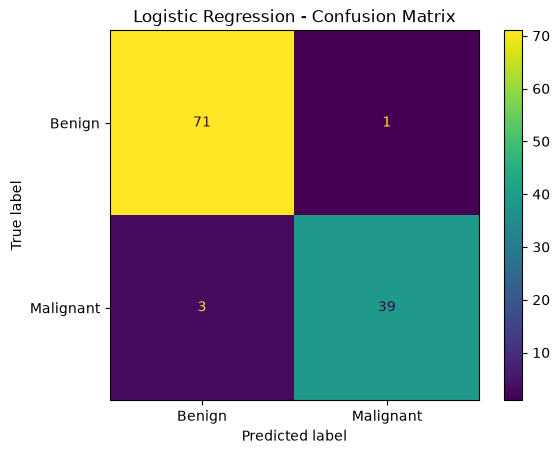


KNN
[[71  1]
 [ 4 38]]


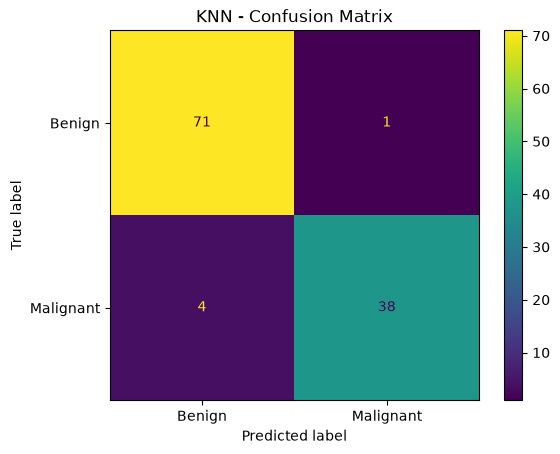


Naive Bayes
[[69  3]
 [ 6 36]]


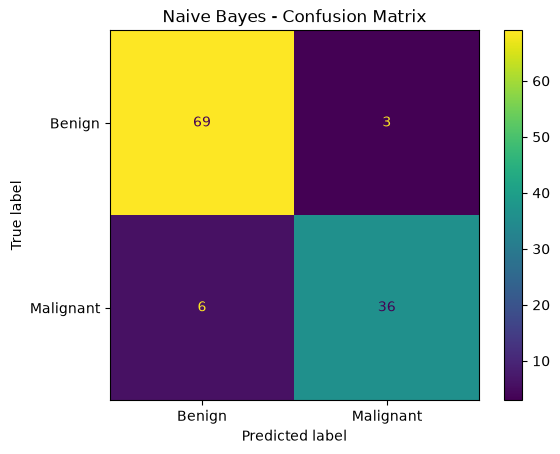


Decision Tree
[[68  4]
 [ 4 38]]


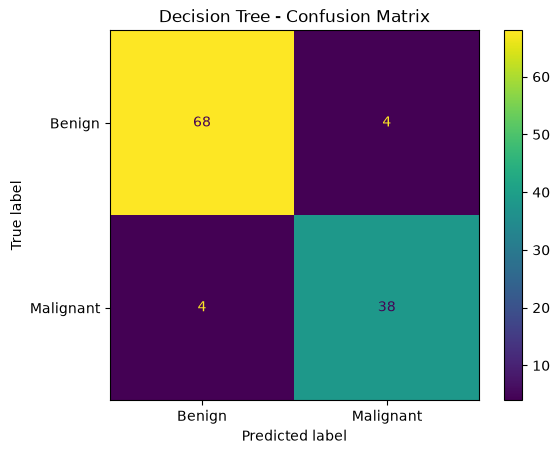


Random Forest
[[72  0]
 [ 3 39]]


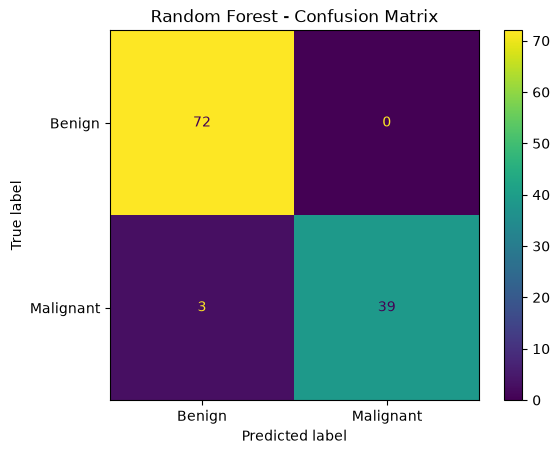


SVM
[[72  0]
 [ 3 39]]


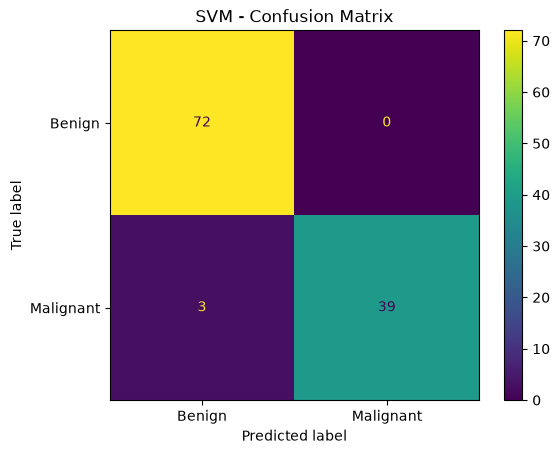


XGBoost
[[72  0]
 [ 3 39]]


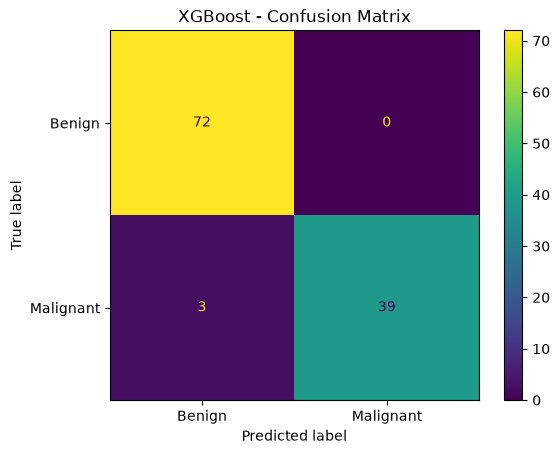

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

for name, model in trained_models.items():
    
    y_pred = model.predict(X_test_scaled)
    
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"\n{name}")
    print(cm)
    
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Benign", "Malignant"]
    ).plot()
    
    plt.title(f"{name} - Confusion Matrix")
    plt.show()
   

## comparison of models

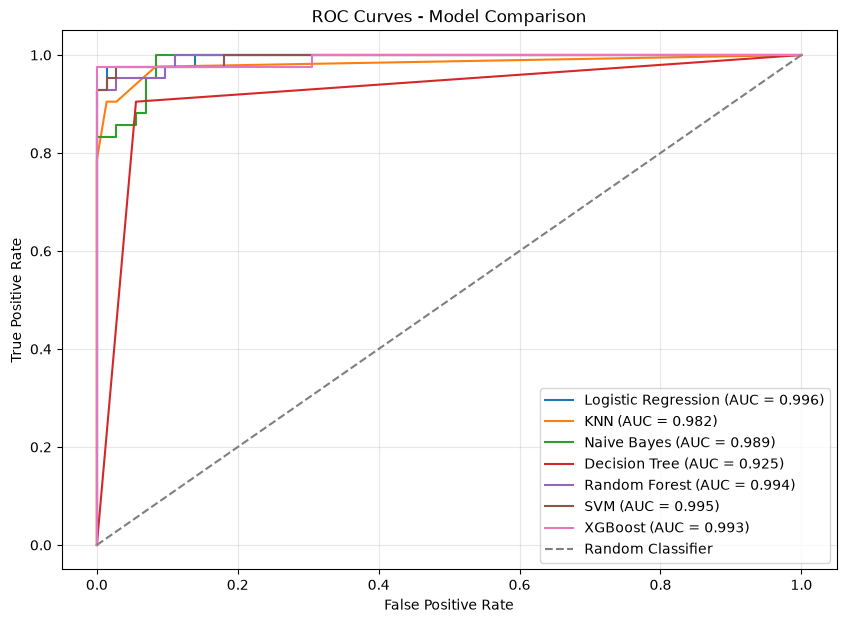

In [15]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 7))

for name, model in trained_models.items():

    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {roc_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Model Comparison")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [16]:
results_df.sort_values(
    by=["ROC-AUC", "Recall", "F1"],
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.964912,0.975000,0.928571,0.951220,0.996032
1,SVM,0.973684,1.000000,0.928571,0.962963,0.994709
2,Random Forest,0.973684,1.000000,0.928571,0.962963,0.994378
3,XGBoost,0.973684,1.000000,0.928571,0.962963,0.992725
4,Naive Bayes,0.921053,0.923077,0.857143,0.888889,0.989087
5,KNN,0.956140,0.974359,0.904762,0.938272,0.982308
6,Decision Tree,0.929825,0.904762,0.904762,0.904762,0.924603


In [18]:
from sklearn.model_selection import GridSearchCV

lr_params = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"]
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=5000, random_state=42),
    lr_params,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

lr_grid.fit(X_train_scaled, y_train)

print("Best Logistic Regression parameters:")
print(lr_grid.best_params_)

print("Best CV ROC-AUC:")
print(round(lr_grid.best_score_, 4))

Best Logistic Regression parameters:
{'C': 10, 'solver': 'lbfgs'}
Best CV ROC-AUC:
0.9959


In [19]:
svm_params = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.001, 0.01, 0.1],
    "kernel": ["rbf", "linear"]
}

svm_grid = GridSearchCV(
    SVC(
        probability=True,
        random_state=42
    ),
    svm_params,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

svm_grid.fit(X_train_scaled, y_train)

print("Best SVM parameters:")
print(svm_grid.best_params_)

print("Best CV ROC-AUC:")
print(round(svm_grid.best_score_, 4))

Best SVM parameters:
{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Best CV ROC-AUC:
0.9955


In [20]:
tuned_models = {
    "Tuned Logistic Regression": lr_grid.best_estimator_,
    "Tuned SVM": svm_grid.best_estimator_
}

tuned_results = []

for name, model in tuned_models.items():

    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    tuned_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

tuned_results_df = pd.DataFrame(tuned_results)

tuned_results_df.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Tuned Logistic Regression,0.9737,0.9756,0.9524,0.9639,0.9864
1,Tuned SVM,0.9825,1.0000,0.9524,0.9756,0.9960


Confusion Matrix:
[[72  0]
 [ 2 40]]


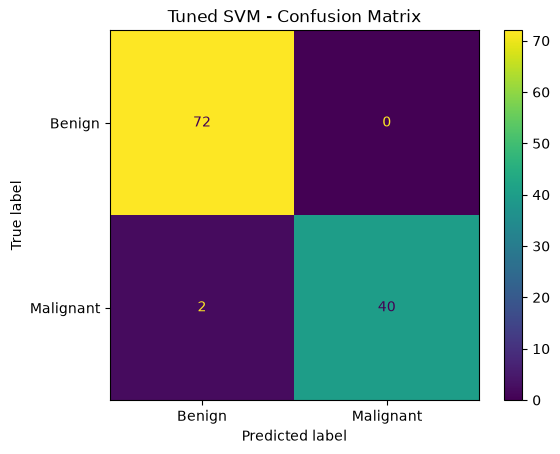

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_model = svm_grid.best_estimator_

y_pred = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Malignant"]
).plot()

plt.title("Tuned SVM - Confusion Matrix")
plt.show()

In [22]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import precision_recall_curve

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

svm_for_threshold = SVC(
    C=10,
    gamma=0.01,
    kernel="rbf",
    probability=True,
    random_state=42
)

train_prob = cross_val_predict(
    svm_for_threshold,
    X_train_scaled,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

precision, recall, thresholds = precision_recall_curve(
    y_train,
    train_prob
)

threshold_table = pd.DataFrame({
    "Threshold": thresholds,
    "Precision": precision[:-1],
    "Recall": recall[:-1]
})

threshold_table[
    threshold_table["Recall"] >= 0.95
].sort_values(
    by=["Recall", "Precision"],
    ascending=False
).head(15)

,Threshold,Precision,Recall
121,0.004164,0.508982,1.0
120,0.004136,0.507463,1.0
119,0.004006,0.505952,1.0
118,0.003983,0.504451,1.0
117,0.003963,0.502959,1.0
116,0.003845,0.501475,1.0
115,0.003816,0.500000,1.0
114,0.003793,0.498534,1.0
113,0.003726,0.497076,1.0
112,0.003693,0.495627,1.0


In [23]:
from sklearn.metrics import f1_score

threshold_table["F1"] = (
    2 * threshold_table["Precision"] * threshold_table["Recall"]
    / (threshold_table["Precision"] + threshold_table["Recall"] + 1e-10)
)

best_threshold_row = threshold_table.loc[
    threshold_table["F1"].idxmax()
]

print("Best threshold:")
print("Threshold:", round(best_threshold_row["Threshold"], 4))
print("Precision:", round(best_threshold_row["Precision"], 4))
print("Recall:", round(best_threshold_row["Recall"], 4))
print("F1:", round(best_threshold_row["F1"], 4))


Best threshold:
Threshold: 0.62
Precision: 0.9939
Recall: 0.9529
F1: 0.973


In [24]:
best_threshold = best_threshold_row["Threshold"]

best_model = svm_grid.best_estimator_

test_prob = best_model.predict_proba(X_test_scaled)[:, 1]

y_test_threshold = (
    test_prob >= best_threshold
).astype(int)

print("Threshold:", round(best_threshold, 4))
print()

print("Accuracy:",
      round(accuracy_score(y_test, y_test_threshold), 4))

print("Precision:",
      round(precision_score(y_test, y_test_threshold), 4))

print("Recall:",
      round(recall_score(y_test, y_test_threshold), 4))

print("F1:",
      round(f1_score(y_test, y_test_threshold), 4))

Threshold: 0.62

Accuracy: 0.9737
Precision: 1.0
Recall: 0.9286
F1: 0.963


In [25]:
cm_threshold = confusion_matrix(
    y_test,
    y_test_threshold
)

print(cm_threshold)

[[72  0]
 [ 3 39]]


In [26]:
import pickle
import os

os.makedirs("../models", exist_ok=True)

final_model = svm_grid.best_estimator_

with open("../models/svm_model.pkl", "wb") as file:
    pickle.dump(final_model, file)

with open("../models/scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

config = {
    "model": "SVM",
    "kernel": "rbf",
    "C": 10,
    "gamma": 0.01,
    "threshold": 0.62,
    "features": list(X.columns)
}

with open("../models/config.pkl", "wb") as file:
    pickle.dump(config, file)

print("Model saved successfully!")
print("Scaler saved successfully!")
print("Config saved successfully!")

Model saved successfully!
Scaler saved successfully!
Config saved successfully!
